* **Bài toán:** Gom cụm khách hàng dựa trên hành vi tiêu dùng (Tuổi, Thu nhập, Điểm chi tiêu).
* **Yêu cầu:** Tự định nghĩa thuật toán K-means và Silhouette score bằng Numpy, không dùng thư viện Machine Learning hỗ trợ. Dữ liệu đầu vào đã được nhóm tiền xử lý chuẩn hóa thành công.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình để hiển thị biểu đồ đẹp hơn trong Jupyter
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Đọc dữ liệu từ file CSV
try:
    df = pd.read_csv('../../DATA/DATA_PREPROCESSING/CUSTOMER/customer_personality_preprocessed.csv')
    print("Nạp dữ liệu thành công! Kích thước tập dữ liệu:", df.shape)
    
    # Chuyển đổi dataframe thành mảng Numpy (chỉ lấy các cột số đã được chuẩn hóa)
    X = df.values
    print("Dữ liệu đã được chuyển sang ma trận Numpy, sẵn sàng tính toán.")
except FileNotFoundError:
    print("Không tìm thấy file 'preprocessed_customers.csv'. Hãy kiểm tra lại đường dẫn.")

Nạp dữ liệu thành công! Kích thước tập dữ liệu: (2237, 24)
Dữ liệu đã được chuyển sang ma trận Numpy, sẵn sàng tính toán.


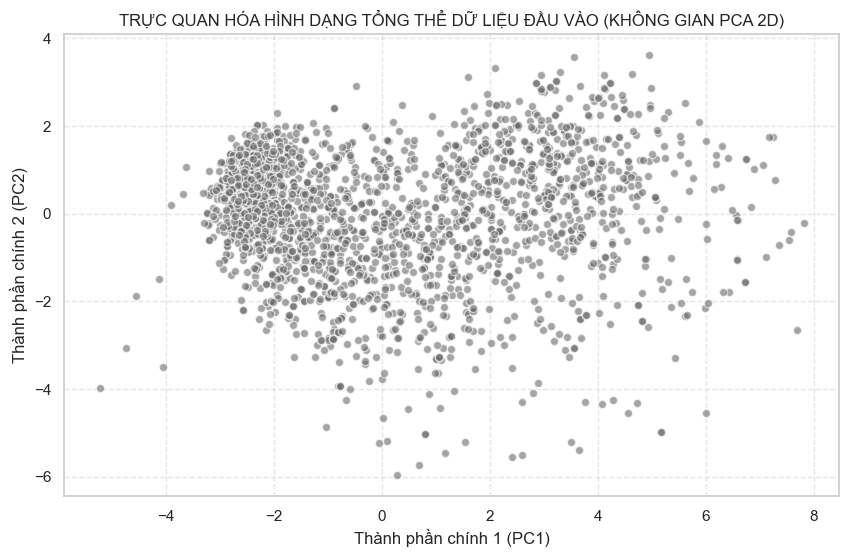

In [3]:
# ==============================================================================
# CELL THÊM VÀO 1: TRỰC QUAN HÓA TỔNG THỂ DỮ LIỆU ĐẦU VÀO (PCA FROM SCRATCH)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Chuẩn hóa trung bình (Mean centering) ma trận dữ liệu X
X_centered = X - np.mean(X, axis=0)

# 2. Tính ma trận hiệp biến (Covariance matrix) của dữ liệu
cov_matrix = np.cov(X_centered, rowvar=False)

# 3. Tìm các trị riêng (eigenvalues) và vectơ riêng (eigenvectors) bằng NumPy
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# 4. Sắp xếp giảm dần trị riêng để lấy 2 vectơ riêng có thành phần chính lớn nhất
sorted_index = np.argsort(eigen_values)[::-1]
pca_components = eigen_vectors[:, sorted_index[:2]]

# 5. Chiếu dữ liệu từ không gian 24 chiều xuống không gian 2 chiều (PC1, PC2)
X_pca = np.dot(X_centered, pca_components)

# 6. Vẽ biểu đồ phân tán (Scatter plot) dữ liệu thô ban đầu
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='dimgray', edgecolors='w', s=35)
plt.title('TRỰC QUAN HÓA HÌNH DẠNG TỔNG THỂ DỮ LIỆU ĐẦU VÀO (KHÔNG GIAN PCA 2D)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [4]:
# Định nghĩa Thuật toán K-Means From Scratch
class KMeansFromScratch:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_ = None

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X, labels):
        new_centroids = np.zeros_like(self.centroids)
        for j in range(self.n_clusters):
            if np.any(labels == j):  # Kiểm tra nếu cluster không rỗng
                new_centroids[j] = X[labels == j].mean(axis=0)
            else:
                # Nếu cluster rỗng, giữ nguyên centroid cũ
                new_centroids[j] = self.centroids[j]
        return new_centroids

    def _init_centroids_plusplus(self, X):
        np.random.seed(self.random_state)
        # Chọn centroid đầu tiên ngẫu nhiên
        idx = np.random.randint(0, X.shape[0])
        centroids = [X[idx]]

        for _ in range(1, self.n_clusters):
            # Tính khoảng cách từ mỗi điểm đến centroid gần nhất đã chọn
            dists = np.min(
                np.linalg.norm(X[:, np.newaxis] - np.array(centroids), axis=2),
                axis=1
            )
            # Chọn điểm tiếp theo với xác suất tỉ lệ với dist²
            probs = dists ** 2 / np.sum(dists ** 2)
            next_idx = np.random.choice(X.shape[0], p=probs)
            centroids.append(X[next_idx])

        return np.array(centroids)

    def fit(self, X):
        # Dùng KMeans++ thay vì random thuần túy để khởi tạo centroids
        self.centroids = self._init_centroids_plusplus(X)
        
        for i in range(self.max_iters):
            # Gán nhãn cho mỗi điểm dữ liệu dựa trên khoảng cách đến centroids
            self.labels = self._assign_clusters(X)
            
            # Lưu trữ centroids cũ để kiểm tra sự thay đổi
            old_centroids = self.centroids.copy()
            
            # Cập nhật centroids bằng cách tính trung bình của các điểm dữ liệu trong mỗi cluster
            new_centroids = self._update_centroids(X, self.labels)
            
            # Kiểm tra sự hội tụ (nếu centroids không thay đổi nhiều)
            self.centroids = new_centroids # Cập nhật centroids sau khi tính toán

            if np.all(np.abs(new_centroids - old_centroids) < self.tol):
                print(f"Hội tụ sau {i+1} vòng lặp.")
                break

        self.labels = self._assign_clusters(X)  # Gán nhãn cuối cùng sau khi hội tụ
        self.inertia_ = 0.0
        for j in range(self.n_clusters):
                    cluster_points = X[self.labels == j]
                    if len(cluster_points) > 0:
                        self.inertia_ += np.sum((cluster_points - self.centroids[j]) ** 2)
                
        return self
    
    def predict(self, X):
        if self.centroids is None:
                    raise ValueError("Mô hình chưa được huấn luyện. Hãy chạy hàm .fit() trước.")
        return self._assign_clusters(X)

In [5]:
def silhouette_score_from_scratch(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return 0.0

    a = np.zeros(n_samples)
    b = np.full(n_samples, np.inf)

    for label in unique_labels:
        mask = (labels == label)
        cluster_size = np.sum(mask)
        X_cluster = X[mask]

        # Tính a(i): mean dist đến các điểm cùng cluster
        if cluster_size > 1:
            # Broadcasting: (cluster_size, cluster_size, n_features)
            dists = np.linalg.norm(
                X_cluster[:, np.newaxis] - X_cluster[np.newaxis, :], axis=2
            )
            a[mask] = dists.sum(axis=1) / (cluster_size - 1)

        # Tính b(i): mean dist đến cluster ngoài gần nhất
        for other_label in unique_labels:
            if other_label == label:
                continue
            other_mask = (labels == other_label)
            X_other = X[other_mask]
            # (n_in_cluster, n_in_other, n_features)
            dists_to_other = np.linalg.norm(
                X_cluster[:, np.newaxis] - X_other[np.newaxis, :], axis=2
            )
            mean_dists = dists_to_other.mean(axis=1)
            b[mask] = np.minimum(b[mask], mean_dists)

    s = (b - a) / np.maximum(a, b)
    return float(np.mean(np.nan_to_num(s)))

In [6]:
df = pd.read_csv('../../DATA/DATA_PREPROCESSING/CUSTOMER/customer_personality_preprocessed.csv')
X = df.values

inertia_list = []
silhouette_list = []
k_range = range(2, 10)

print("Bắt đầu quét danh sách K...")
for k in k_range:
    model = KMeansFromScratch(n_clusters=k, random_state=42)
    model.fit(X)

    inertia_list.append(model.inertia_)

    labels = model.predict(X)
    score = silhouette_score_from_scratch(X, labels)
    silhouette_list.append(score)

    print(f"K={k} | Inertia={model.inertia_:.2f} | Silhouette={score:.4f}")

Bắt đầu quét danh sách K...
Hội tụ sau 9 vòng lặp.
K=2 | Inertia=42504.71 | Silhouette=0.2562
Hội tụ sau 12 vòng lặp.
K=3 | Inertia=39297.43 | Silhouette=0.1664
Hội tụ sau 19 vòng lặp.
K=4 | Inertia=36693.79 | Silhouette=0.1706
Hội tụ sau 28 vòng lặp.
K=5 | Inertia=35658.00 | Silhouette=0.1591
Hội tụ sau 25 vòng lặp.
K=6 | Inertia=34571.99 | Silhouette=0.1270
Hội tụ sau 26 vòng lặp.
K=7 | Inertia=33159.05 | Silhouette=0.1383
Hội tụ sau 18 vòng lặp.
K=8 | Inertia=32350.20 | Silhouette=0.1255
Hội tụ sau 47 vòng lặp.
K=9 | Inertia=31161.53 | Silhouette=0.0928


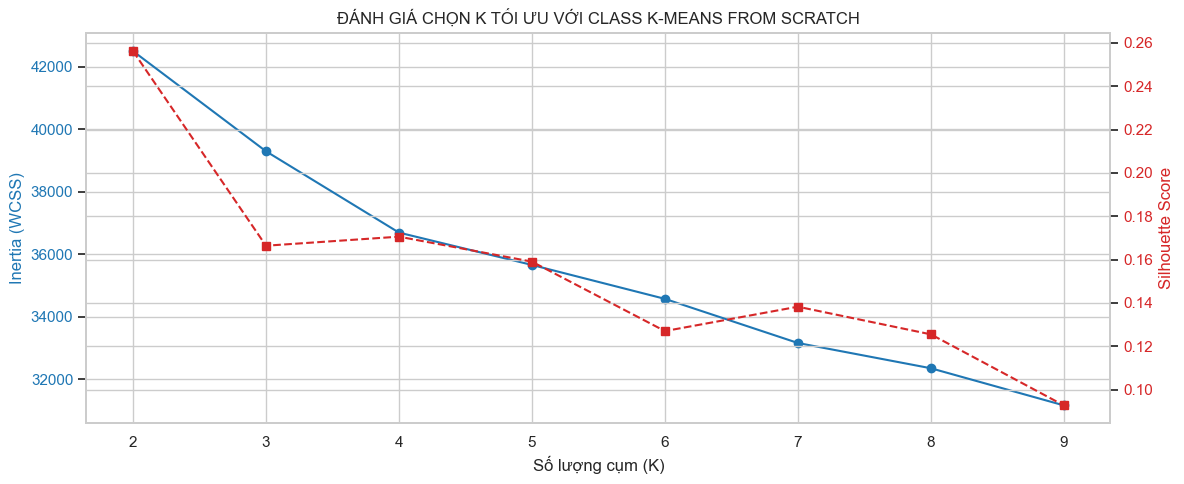

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Số lượng cụm (K)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_range, inertia_list, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_list, marker='s', color=color,
         linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('ĐÁNH GIÁ CHỌN K TỐI ƯU VỚI CLASS K-MEANS FROM SCRATCH')
fig.tight_layout()
plt.show()

In [11]:
optimal_k = 4

final_model = KMeansFromScratch(n_clusters=optimal_k, random_state=42)
final_model.fit(X)

df['Cluster'] = final_model.predict(X)

print("=== SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI PHÂN KHÚC ===")
print(df['Cluster'].value_counts().sort_index())


cluster_summary = df.groupby('Cluster').mean().T

# 2. Loại bỏ các cột định danh hoặc cột hằng số vô nghĩa (nếu có) cho bảng gọn hơn
cols_to_drop = ['ID', 'Z_CostContact', 'Z_Revenue']
cluster_summary = cluster_summary.drop(index=[c for c in cols_to_drop if c in cluster_summary.index], errors='ignore')

# 3. Tạo style trang trí cho bảng
styled_output = cluster_summary.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format("{:,.2f}") \
    .set_caption("BẢNG PHÂN TÍCH ĐẶC TRƯNG CHÂN DUNG CÁC PHÂN KHÚC KHÁCH HÀNG") \
    .set_properties(**{
        'text-align': 'right',
        'padding': '8px',
        'font-size': '13px',
        'border-bottom': '1px solid #e6e6e6'
    }) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f7f9fa'), ('color', '#333'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('color', '#1d3557'), ('font-size', '16px')]}
    ])

# 4. Gọi bảng ra để hiển thị trực tiếp trong Jupyter Notebook
styled_output

Hội tụ sau 19 vòng lặp.
=== SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI PHÂN KHÚC ===
Cluster
0     540
1    1031
2     497
3     169
Name: count, dtype: int64


Cluster,0,1,2,3
Education,0.24,-0.09,-0.10,0.07
Marital_Status,0.05,-0.00,-0.07,0.06
Income,0.15,-0.67,0.83,1.18
MntWines,0.45,-0.78,0.55,1.70
MntFruits,-0.21,-0.53,1.08,0.74
MntMeatProducts,-0.18,-0.64,1.07,1.33
MntFishProducts,-0.24,-0.56,1.17,0.73
MntSweetProducts,-0.20,-0.53,1.01,0.93
MntGoldProds,0.26,-0.55,0.65,0.63
NumDealsPurchases,0.95,-0.20,-0.40,-0.66


In [ ]:
# ==============================================================================
# XUẤT FILE CSV KẾT QUẢ PHÂN CỤM
# ==============================================================================

# Đọc lại file CSV gốc để giữ nguyên định dạng ban đầu
df_original = pd.read_csv('../../DATA/DATA_PREPROCESSING/CUSTOMER/customer_personality_preprocessed.csv')

# Gán nhãn cụm từ mô hình đã huấn luyện vào dataframe gốc
df_original['Cluster'] = final_model.predict(X)

# Xuất ra file CSV kết quả
output_path = '../../DATA/DATA_PREPROCESSING/CUSTOMER/customer_personality_clustered.csv'
df_original.to_csv(output_path, index=False)

print(f"Đã xuất file CSV thành công: {output_path}")
print(f"   Kích thước file: {df_original.shape[0]} dòng x {df_original.shape[1]} cột")
print(f"\nPhân bố các cụm:")
print(df_original['Cluster'].value_counts().sort_index().to_string())
print(f"\n5 dòng đầu tiên:")
print(df_original.head())

✅ Đã xuất file CSV thành công: ../../DATA/DATA_PREPROCESSING/CUSTOMER/customer_personality_clustered.csv
   Kích thước file: 2237 dòng x 25 cột

📊 Phân bố các cụm:
Cluster
0     540
1    1031
2     497
3     169

🔍 5 dòng đầu tiên:
   Education  Marital_Status    Income  MntWines  MntFruits  MntMeatProducts  \
0  -0.819827       -1.348103  0.235681  0.983671   1.554623         1.680253   
1  -0.819827       -1.348103 -0.235144 -0.870717  -0.636422        -0.713250   
2  -0.819827        0.741783  0.773613  0.362570   0.572430        -0.176928   
3  -0.819827        0.741783 -1.021503 -0.870717  -0.560868        -0.651196   
4   1.529387        0.741783  0.241868 -0.389289   0.421324        -0.216820   

   MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  ...  \
0         2.461700          1.475877      0.846061           0.348371  ...   
1        -0.650275         -0.631440     -0.729569          -0.169096  ...   
2         1.345050         -0.147000     -0.037829   

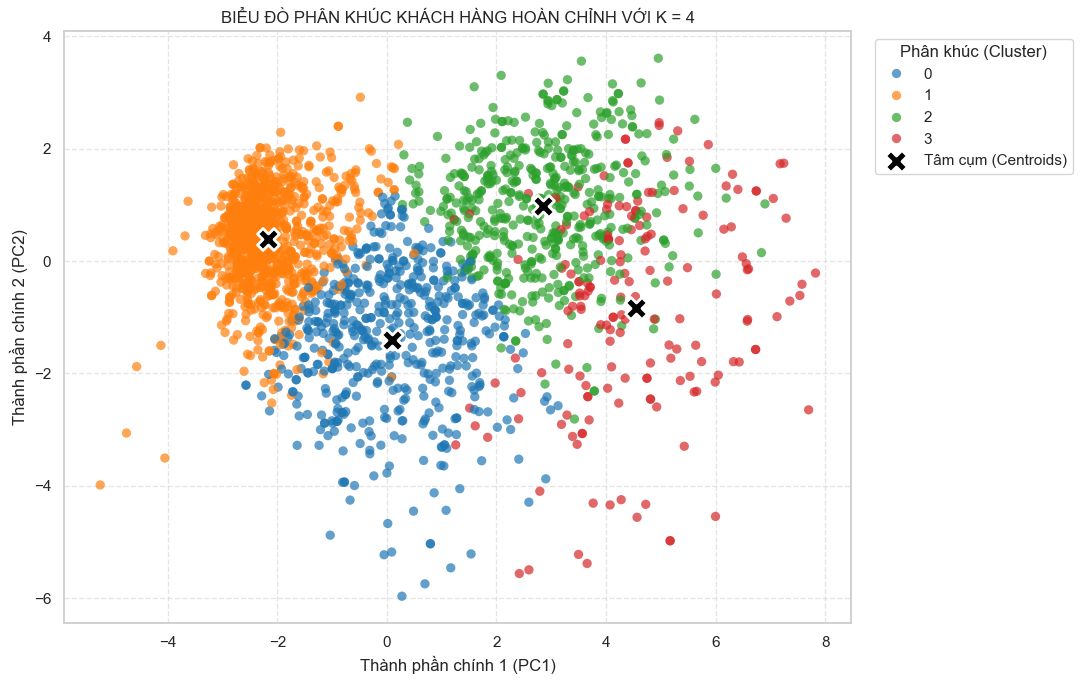

In [23]:
# ==============================================================================
# CELL THÊM VÀO 2: TRỰC QUAN HÓA KẾT QUẢ GOM CỤM TỐI ƯU VỚI TÂM CỤM (CENTROIDS)
# ==============================================================================
import seaborn as sns

# 1. Lấy nhãn cụm đã được mô hình dự đoán từ dữ liệu dataframe
cluster_labels = df['Cluster'].values

# 2. Chiếu các tâm cụm (Centroids) 24 chiều của mô hình xuống không gian PCA 2D ở trên
# Ta dùng cùng một phép trừ mean và nhân ma trận chuyển đổi như dữ liệu đầu vào
centroids_centered = final_model.centroids - np.mean(X, axis=0)
centroids_pca = np.dot(centroids_centered, pca_components)

# 3. Vẽ biểu đồ phân tán kết quả gom cụm bằng Seaborn để tự động tạo bảng màu đẹp
plt.figure(figsize=(11, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=cluster_labels, 
    palette='tab10', 
    alpha=0.7, 
    s=45, 
    edgecolor='none'
)

# 4. Vẽ các vị trí tâm cụm (Centroids) lên bản đồ bằng ký hiệu chữ 'X' màu đen nổi bật
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], 
    color='black', 
    marker='X', 
    s=250, 
    label='Tâm cụm (Centroids)', 
    edgecolor='white', 
    linewidth=2
)

# 5. Cấu hình hiển thị thông tin đồ thị
plt.title(f'BIỂU ĐỒ PHÂN KHÚC KHÁCH HÀNG HOÀN CHỈNH VỚI K = {final_model.n_clusters}')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.legend(title='Phân khúc (Cluster)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()